In [1]:
import scanpy as sc 
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA

import scipy.sparse as sp 
import warnings
import torch

warnings.filterwarnings("ignore")

import os
import ctypes
import sys


os.environ["R_HOME"] = "/home/pxy/miniconda3/envs/r40/lib/R"


try:

    libR_path = "/home/pxy/miniconda3/envs/r40/lib/R/lib/libR.so"

    ctypes.CDLL(libR_path, mode=ctypes.RTLD_GLOBAL)
    print("✅ 成功强制加载 libR.so")
except OSError as e:
    print(f"❌ 加载失败: {e}")


sys.path.append("..") 

import models
import rpy2.robjects as robjects
print("R 环境路径:", robjects.r['R.home']()[0])

models.fix_seed(0)

✅ 成功强制加载 libR.so
R 环境路径: /home/pxy/miniconda3/envs/r40/lib/R


In [ ]:
import scanpy as sc
import pandas as pd
import os
import anndata as ad
import numpy as np


data_dir = "/home/pxy/home/pxy/data2/Data/Mouse_Somatosensory_Cortex/" 
loom_file = os.path.join(data_dir, "osmFISH_SScortex_mouse_all_cells.loom")


adata = ad.read_loom(loom_file)
adata.var_names_make_unique()


adata.obsm['spatial'] = adata.obs[['X', 'Y']].values.astype(float)


spagic_cortical_regions = [
    'Pia Layer 1',
    'Layer 2-3 lateral', 
    'Layer 2-3 medial', 
    'Layer 3-4', 
    'Layer 4', 
    'Layer 5', 
    'Layer 6'
]


adata = adata[adata.obs['Region'].isin(spagic_cortical_regions)].copy()


adata.obs['Region'] = adata.obs['Region'].astype('category')


print(f"Dataset: Mouse Somatosensory Cortex (MSC - SpaGIC version)")
print(f"Total Cells: {adata.n_obs}")  
print(f"Available Labels: {adata.obs['Region'].nunique()}") 
print(f"NA spots in Region: {adata.obs['Region'].isna().sum()}")

print("\nFinal Annotation Details (7 Domains):")
print(adata.obs["Region"].value_counts())



Dataset: Mouse Somatosensory Cortex (MSC - SpaGIC version)
Total Cells: 3405
Available Labels: 7
NA spots in Region: 0

Final Annotation Details (7 Domains):
Region
Layer 6              1015
Layer 4              1002
Layer 2-3 medial      549
Layer 5               295
Layer 2-3 lateral     254
Pia Layer 1           159
Layer 3-4             131
Name: count, dtype: int64


In [ ]:
figures_dir = "../figures_MSC_osmFISH"

In [6]:
print(f"当前 adata 包含 {adata.n_obs} 个细胞和 {adata.n_vars} 个基因")

当前 adata 包含 3405 个细胞和 33 个基因


In [7]:
adata = models.preprocess(adata)
# adata.obsm["X_pca"] = PCA(n_components=200, random_state=0).fit_transform(adata.X)
g_spatia = models.prepare_graph(adata, "spatial",n_neighbors=6)
g_expr = models.prepare_graph(adata, "expr", metric="euclidean",n_neighbors=10,n_comps=None)
graph_dict = {"spatial": g_spatia, "expr":g_expr}

Preprocessing data ---------------->
正在构建图: spatial, 使用度量: cosine ...
  -> 使用空间坐标 (euclidean)
  -> 计算最近邻 (NearestNeighbors)...
  -> 对称化与归一化...
spatial graph created successfully <----

正在构建图: expr, 使用度量: euclidean ...
  -> 跳过 PCA，直接使用原始表达量数据
  -> 计算最近邻 (NearestNeighbors)...
  -> 对称化与归一化...
expr graph created successfully <----



In [8]:
n_clusters = adata.obs['Region'].nunique()

In [ ]:
model = models.model_TwoStage(
    adata.X, 
    graph_dict, 
    n_clusters=n_clusters,
    dim_input=33,
    pretrain_epochs=100,   # 预训练100轮
    finetune_epochs=100,   # 训练100轮
    gamma=0.0,             # 重构损失权重
    kappa=1.5,             # 对比损失权重
    theta=2.0,
    dim_hidden=24,
    freeze_encoder=False,   # 冻结预训练编码器
    graph_corr=0.2,
    dropout=0.0,
    gate_bias=3.0,
    residual_weight=0.2
)

In [10]:
pred, embed, gated_weights = model.train()

Stage 1: Pre-training Shared Encoder


Pretrain:  21%|██        | 21/100 [00:02<00:06, 12.02it/s]

  Pretrain Epoch 10: Rec Loss = 0.958145
  Pretrain Epoch 20: Rec Loss = 0.906889


Pretrain:  43%|████▎     | 43/100 [00:03<00:01, 30.90it/s]

  Pretrain Epoch 30: Rec Loss = 0.864851
  Pretrain Epoch 40: Rec Loss = 0.839569
  Pretrain Epoch 50: Rec Loss = 0.821628


...

  Train Epoch 80: Loss = 12.307040,Rec Loss = 0.991984, Contrast Loss = 8.087104, Smooth Loss = 0.088192


Finetune:  91%|█████████ | 91/100 [00:16<00:01,  7.04it/s]

  Train Epoch 90: Loss = 12.286615,Rec Loss = 0.993558, Contrast Loss = 8.079023, Smooth Loss = 0.084040


Finetune: 100%|██████████| 100/100 [00:17<00:00,  5.75it/s]

  Train Epoch 100: Loss = 12.270661,Rec Loss = 0.994770, Contrast Loss = 8.072525, Smooth Loss = 0.080937

  Finetune Epoch 100:
    Total Loss   = 12.2707
    Rec Loss     = 0.9948
    Contrast Loss = 8.0725
    Smooth Loss = 0.0809

✓ Finetune finished (max epochs reached)


In [11]:
adata.obsm["model_twostage"] = embed
models.clustering(adata, n_clusters, key="model_twostage", refinement=True,cluster_methods='kmeans')


adata_filtered = adata[adata.obs.Region.notna()]
ARI_kmeans = adjusted_rand_score(adata_filtered.obs["Region"], 
                          adata_filtered.obs["kmeans_refined"])
print(f"\nFinal ARI: {ARI_kmeans:.4f}")



Final ARI: 0.6780


In [12]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score
mask = adata.obs.Region.notna()
X = embed[mask]
labels = adata.obs["kmeans_refined"][mask]

# 1. 计算 SC 指数
sc_val = silhouette_score(X, labels)

# 2. 计算 CH 指数
ch_val = calinski_harabasz_score(X, labels)


print(f"Silhouette Coefficient (SC): {sc_val:.4f}")
print(f"Calinski-Harabasz Index (CH): {ch_val:.4f}")

Silhouette Coefficient (SC): 0.2352
Calinski-Harabasz Index (CH): 1349.3945


In [13]:
from sklearn.metrics import normalized_mutual_info_score


adata_filtered = adata[adata.obs.Region.notna()]


NMI_kmeans = normalized_mutual_info_score(adata_filtered.obs["Region"], 
                                          adata_filtered.obs["kmeans_refined"])

print(f"\nFinal Results on:")
print(f"ARI: {ARI_kmeans:.4f}")
print(f"NMI: {NMI_kmeans:.4f}")


Final Results on:
ARI: 0.6780
NMI: 0.6497


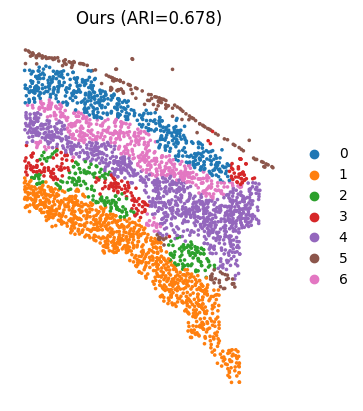

In [ ]:
adata.obs["model"] = adata.obs["kmeans_refined"]
axes = sc.pl.spatial(
    adata,
    color=["model"],
    spot_size=350,
    show=False,
    frameon=False,
    title=[f"Ours (ARI={round(ARI_kmeans, 3)})"]
)

ax = axes[0] if isinstance(axes, list) else axes

# 纠正方向
ax.invert_yaxis() 



ax.set_aspect('equal')

plt.savefig(f"{figures_dir}/MSC_spatial.png", bbox_inches='tight', dpi=300)
plt.show()
plt.close()

In [ ]:
import scanpy as sc
adata.obsm["embed"] = embed

sc.pp.neighbors(adata, use_rep="embed", n_neighbors=15)


sc.tl.umap(adata)

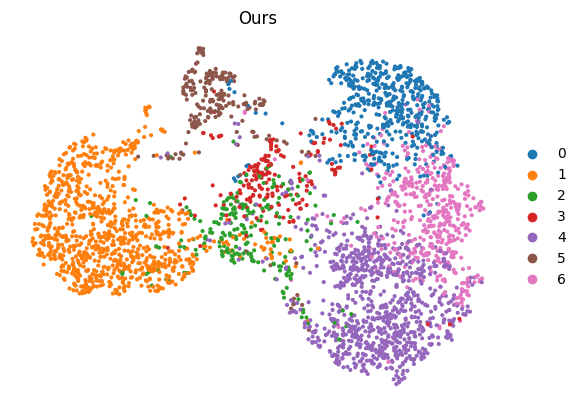

In [ ]:
sc.pl.umap(
    adata, 
    color=["kmeans_refined"], 
    title="Ours",
    show=False,
    frameon=False
)
plt.savefig(f"{figures_dir}/MSC_UMAP_ours.png", bbox_inches='tight', dpi=300)
plt.show()
plt.close()

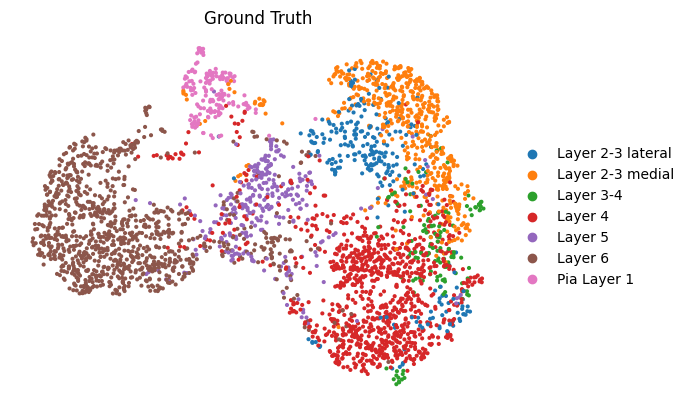

In [ ]:
sc.pl.umap(
    adata, 
    color=["Region"], 
    title="Ground Truth",
    show=False,
    frameon=False
)
plt.savefig(f"{figures_dir}/MSC_UMAP_groundtruth.png", bbox_inches='tight', dpi=300)
plt.show()
plt.close()

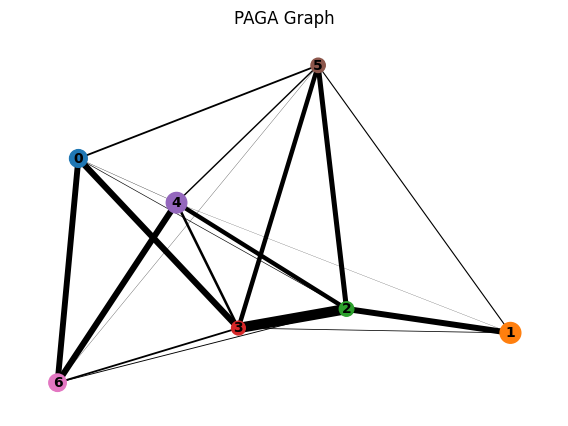

In [20]:
sc.tl.paga(adata, groups="kmeans_refined")


sc.pl.paga(adata, color="kmeans_refined", 
           title=f"PAGA Graph",
           frameon=False,
           show=False)


plt.savefig(f"{figures_dir}/MSC_paga.png", bbox_inches='tight',dpi=300)
plt.show()
plt.close()

✅ UMAP saved to: figures_MSC_osmFISH/MSC_umap_ours+groundtruth.png


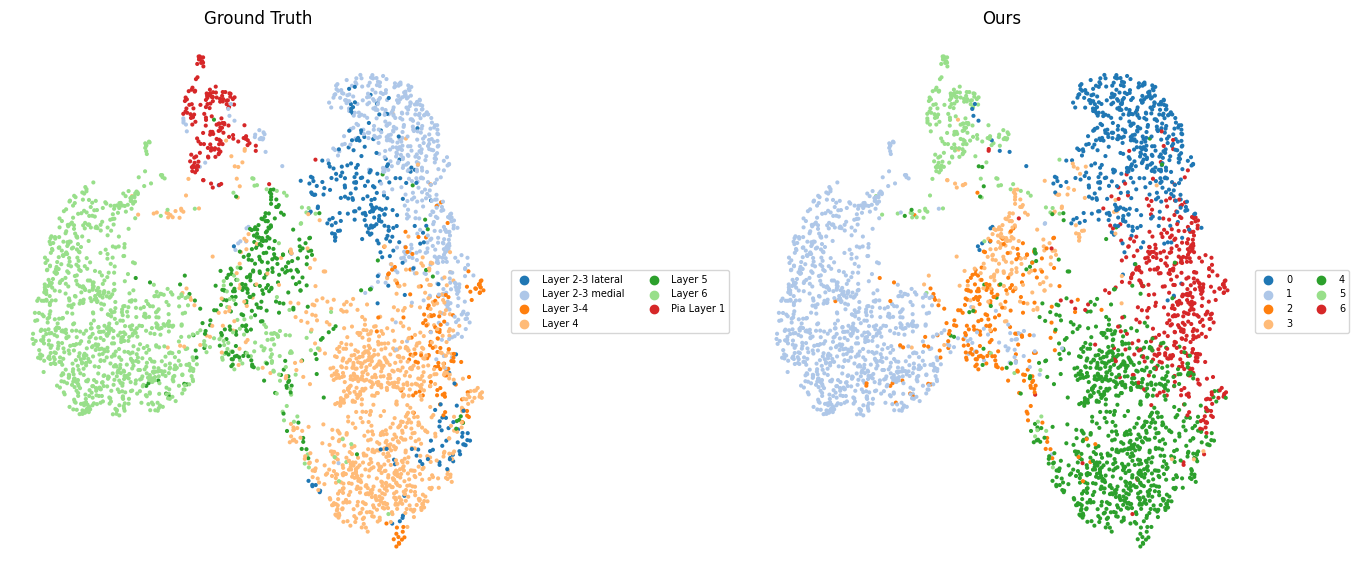

In [21]:

import matplotlib.pyplot as plt
import scanpy as sc

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

cluster_palette = sc.pl.palettes.vega_20

sc.pl.umap(
    adata, 
    color="Region", 
    title="Ground Truth",
    ax=axes[0], 
    show=False,
    palette=cluster_palette,
    frameon=False
)

axes[0].legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2, fontsize=7)


sc.pl.umap(
    adata, 
    color="kmeans_refined", 
    title="Ours",
    ax=axes[1], 
    show=False,
    palette=cluster_palette,
    frameon=False
)

axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2, fontsize=7)


plt.subplots_adjust(wspace=0.5) 


save_path = f"{figures_dir}/MSC_umap_ours+groundtruth.png"
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"✅ UMAP saved to: {save_path}")


plt.show()
plt.close()